# Volatility Estimators and Volatility Cones

- Implments alternative volatility estimators described in the text (Volatility Trading by Euan Sinclair)
- TODO: build volatility cones, discretionary set up for IV-RV spread trade

In [ ]:
import pandas as pd
from core.strategy.es_vol_trading.marketdata import MarketData as MD
from core.strategy.es_vol_trading.estimator import *

In [ ]:
df = pd.read_parquet("../../data/minute_data/aapl_30m.parquet")
iv = pd.read_parquet("../../data/minute_data/aapl_iv_30m.parquet")

### MarketData
- Get 30mins bar data
- IBKR data is split adjusted, not dividend adjusted
- Use dividend to adjust the price for dividends

In [3]:
params = {
    "df": df,
    "freq": "30m",
    "symbol": "AAPL",
    "dividends": {
        "2024-11-08": 0.25,
        "2025-02-10": 0.25,
        "2025-05-12": 0.26,
        "2025-08-11": 0.26,
        "2025-11-10": 0.26,
        "2026-02-09": 0.26,
        "2026-05-11": 0.27
    }
}

In [4]:
md = MD(**params)
md.adj_factor
px = md.adj_prices.copy()

                           adj_factor
date                                 
2024-11-08 00:00:00-05:00    0.992561
2025-02-10 00:00:00-05:00    0.993652
2025-05-12 00:00:00-04:00    0.994744
2025-08-11 00:00:00-04:00    0.996048
2025-11-10 00:00:00-05:00    0.997178
2026-02-09 00:00:00-05:00    0.998145
2026-05-11 00:00:00-04:00    0.999079


In [5]:
estimator_params = {
    "symbol": "AAPL",
    "n_days": 30,
    "px": px,
    "px_freq": "30m"
}

In [6]:
cc = CloseCloseEstimator(**estimator_params)
pe = ParkinsonEstimator(**estimator_params)
gk = GarmanKlassEstimator(**estimator_params)
rs = RogerSatchellEstimator(**estimator_params)
yz = YangZhangEstimator(**estimator_params)

<Axes: >

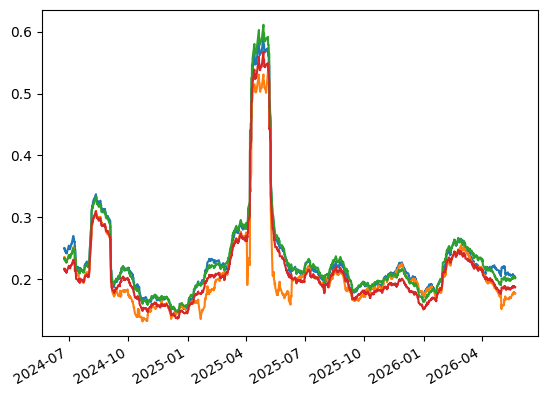

In [22]:
# cc.adjusted_estimate.plot()
pe.adjusted_estimate.plot()
gk.adjusted_estimate.plot()
rs.adjusted_estimate.plot()
yz.adjusted_estimate.plot()